In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [28]:
df = pd.read_csv('Automobile.csv')

In [29]:
df.head()

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


In [31]:
print("Rows and Columns:", df.shape)

Rows and Columns: (398, 9)


In [36]:
print("Columns:", df.columns)

Columns: Index(['name', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin'], dtype='object')


In [37]:
print("Data Types:", df.dtypes)

Data Types: name             object
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
dtype: object


In [38]:
print("Missing Values:", df.isnull().sum())

Missing Values: name            0
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [39]:
print("Info:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          398 non-null    object 
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
Info: None


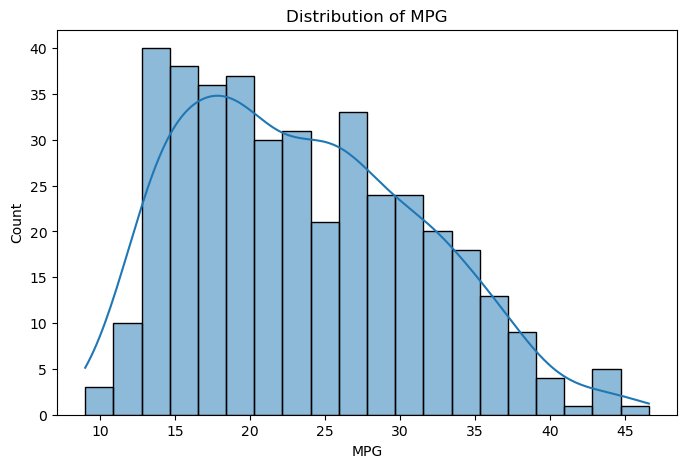

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(df["mpg"], bins=20, kde=True)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")
plt.show()

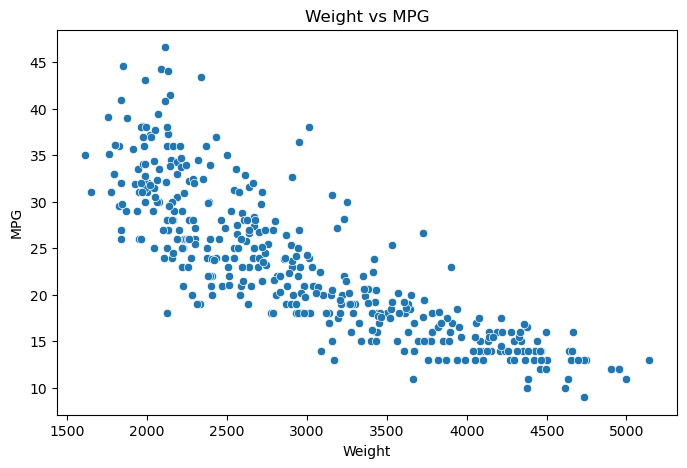

In [48]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["weight"], y=df["mpg"])
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

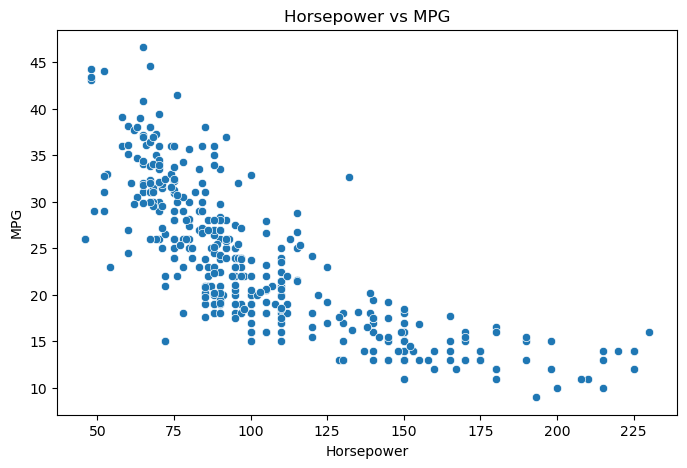

In [49]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["horsepower"], y=df["mpg"])
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

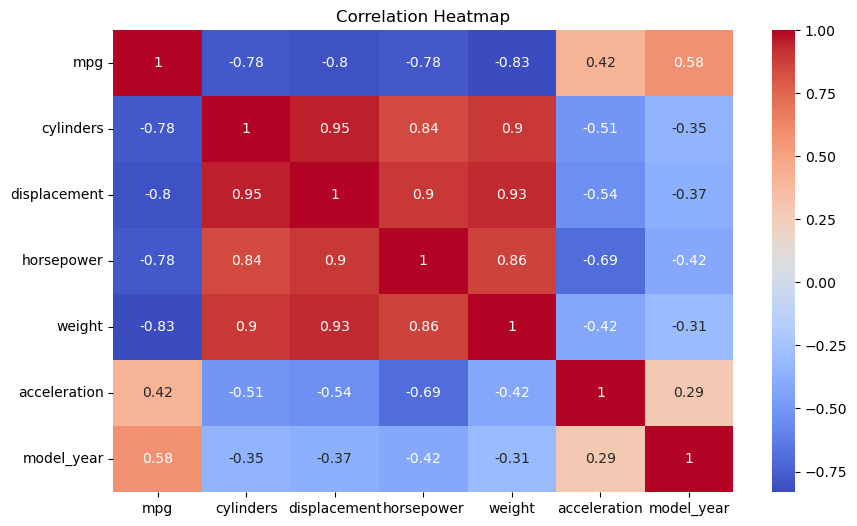

In [50]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

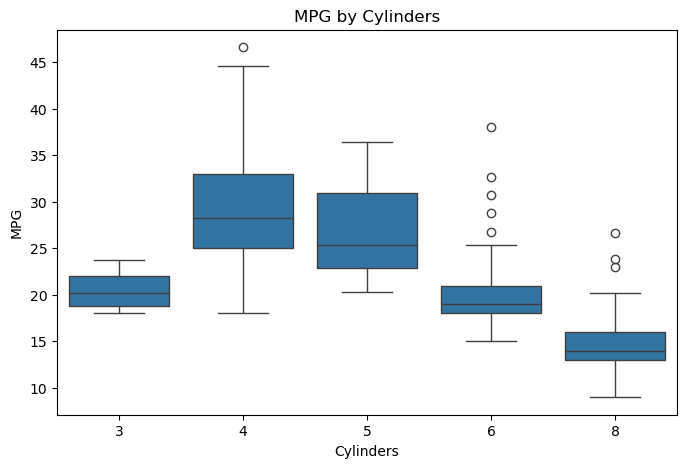

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["cylinders"], y=df["mpg"])
plt.title("MPG by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.show()

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [53]:
# Make a fresh copy of the cleaned dataset
data = df.copy()

In [70]:
# Convert horsepower to numeric
data["horsepower"] = pd.to_numeric(data["horsepower"], errors="coerce")

In [71]:
# Fill missing horsepower values with median
data["horsepower"] = data["horsepower"].fillna(data["horsepower"].median())

In [72]:
# Drop the name column if it exists
data = data.drop(columns=["name"], errors="ignore")

In [73]:
# Remove duplicate rows
data = data.drop_duplicates()

In [74]:
# Check missing values
print(data.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [77]:
# Encode origin column
le = LabelEncoder()
data["origin"] = le.fit_transform(data["origin"])

In [78]:
# Split features and target
X = data.drop("mpg", axis=1)
y = data["mpg"]

In [79]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [ ]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [81]:
# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (318, 7)
X_test: (80, 7)
y_train: (318,)
y_test: (80,)


In [82]:
from sklearn.linear_model import LinearRegression

In [83]:
# Create the model
lr = LinearRegression()

In [84]:
# Train the model
lr.fit(X_train, y_train)

LinearRegression()

In [85]:
# Predict on test data
y_pred_lr = lr.predict(X_test)

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [87]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 2.4303932104749437
MSE: 8.882879429686154
RMSE: 2.980415982658487
R2 Score: 0.8347876703359955


In [88]:
from sklearn.ensemble import RandomForestRegressor

In [89]:
# Create the model
rf = RandomForestRegressor(random_state=42)

In [90]:
# Train the model
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [91]:
# Predict on test data
y_pred_rf = rf.predict(X_test)

In [92]:
print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 1.614
MSE: 4.754098599999998
RMSE: 2.1803895523506798
R2 Score: 0.9115787047009224


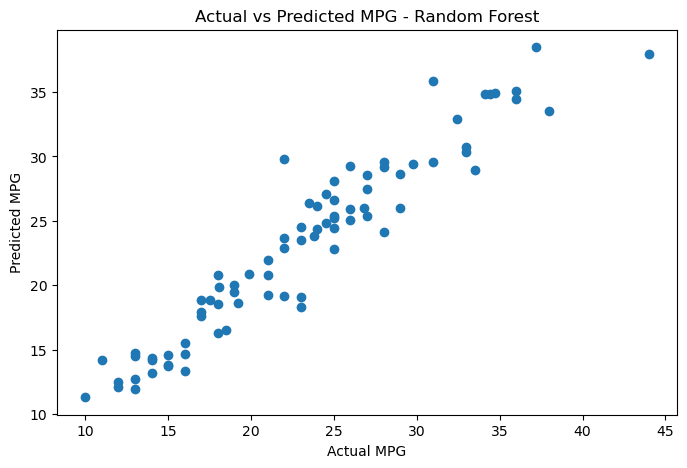

In [93]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG - Random Forest")
plt.show()

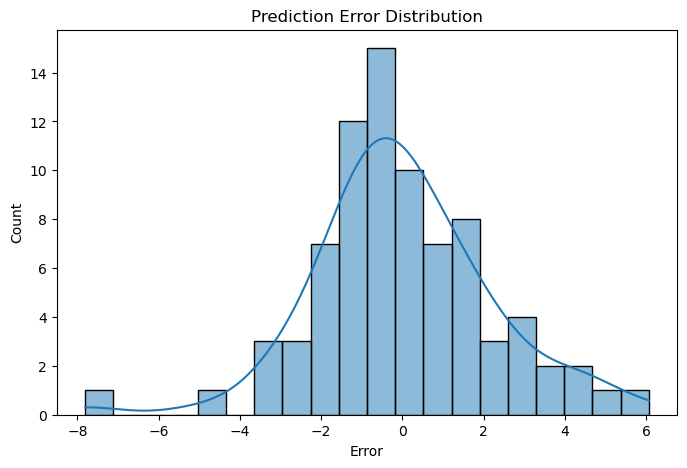

In [94]:
errors = y_test - y_pred_rf

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=20, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()

In [95]:
import joblib

joblib.dump(rf, "car_mpg_model.pkl")
joblib.dump(le, "origin_encoder.pkl")

['origin_encoder.pkl']

In [96]:
# Load model
model = joblib.load("car_mpg_model.pkl")
encoder = joblib.load("origin_encoder.pkl")

In [102]:
sample = pd.DataFrame([[4, 150, 100, 2500, 15, 70, 1]], columns=[
    "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
])

In [103]:
prediction = model.predict(sample)
print("Sample Prediction:", prediction)

Sample Prediction: [23.654]


In [99]:
!pip install streamlit


  Attempting uninstall: smmap

    Found existing installation: smmap 5.0.3

    Uninstalling smmap-5.0.3:

      Successfully uninstalled smmap-5.0.3

  Attempting uninstall: packaging

    Found existing installation: packaging 25.0

    Uninstalling packaging-25.0:

      Successfully uninstalled packaging-25.0

   ---------------------------------------- 2/2 [packaging]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
!streamlit --version

Streamlit, version 1.45.1
